# Project 2: Customer Segmentation & RFM Analysis
## Notebook 1: RFM Score Calculation

**Dataset:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
**Tools:** Python, pandas, numpy, matplotlib, seaborn  
**Tujuan:** Menghitung RFM score setiap pelanggan sebagai dasar segmentasi



---
## Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f8f9fa',
    'axes.grid'       : True,
    'grid.color'      : 'white',
    'grid.linewidth'  : 1.2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

COLORS = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']
C1, C2, C3, C4, C5 = COLORS

# Load dataset (sheet Year 2010-2011)
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

print('Dataset loaded!')
print(f'   Shape  : {df.shape}')
print(f'   Kolom  : {list(df.columns)}')
display(df.head())

Dataset loaded!
   Shape  : (541910, 8)
   Kolom  : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
## Data Cleaning

In [2]:
print('Sebelum Cleaning')
print(f'Total baris       : {len(df):,}')
print(f'Missing Customer  : {df["Customer ID"].isna().sum():,}')
print(f'Invoice negatif   : {(df["Quantity"] < 0).sum():,}  (retur)')
print(f'Price negatif     : {(df["Price"] < 0).sum():,}')
print(f'Duplikasi         : {df.duplicated().sum():,}')

df_clean = df.copy()

# Hapus missing Customer ID (tidak bisa diidentifikasi)
df_clean = df_clean.dropna(subset=['Customer ID'])

# Hapus transaksi retur (Quantity < 0) dan harga tidak valid
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]

# Hapus duplikasi
df_clean = df_clean.drop_duplicates()

# Pastikan Customer ID sebagai integer
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# Tambah kolom TotalPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Pastikan InvoiceDate datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print('\nSesudah Cleaning')
print(f'Total baris       : {len(df_clean):,}')
print(f'Unique customers  : {df_clean["Customer ID"].nunique():,}')
print(f'Periode data      : {df_clean["InvoiceDate"].min().date()} s/d {df_clean["InvoiceDate"].max().date()}')
print(f'Negara            : {df_clean["Country"].nunique()} negara')
print(f'Total revenue     : £{df_clean["TotalPrice"].sum():,.2f}')

Sebelum Cleaning
Total baris       : 541,910
Missing Customer  : 135,080
Invoice negatif   : 10,624  (retur)
Price negatif     : 2
Duplikasi         : 5,268

Sesudah Cleaning
Total baris       : 392,693
Unique customers  : 4,338
Periode data      : 2010-12-01 s/d 2011-12-09
Negara            : 37 negara
Total revenue     : £8,887,226.89


---
## Eksplorasi Awal

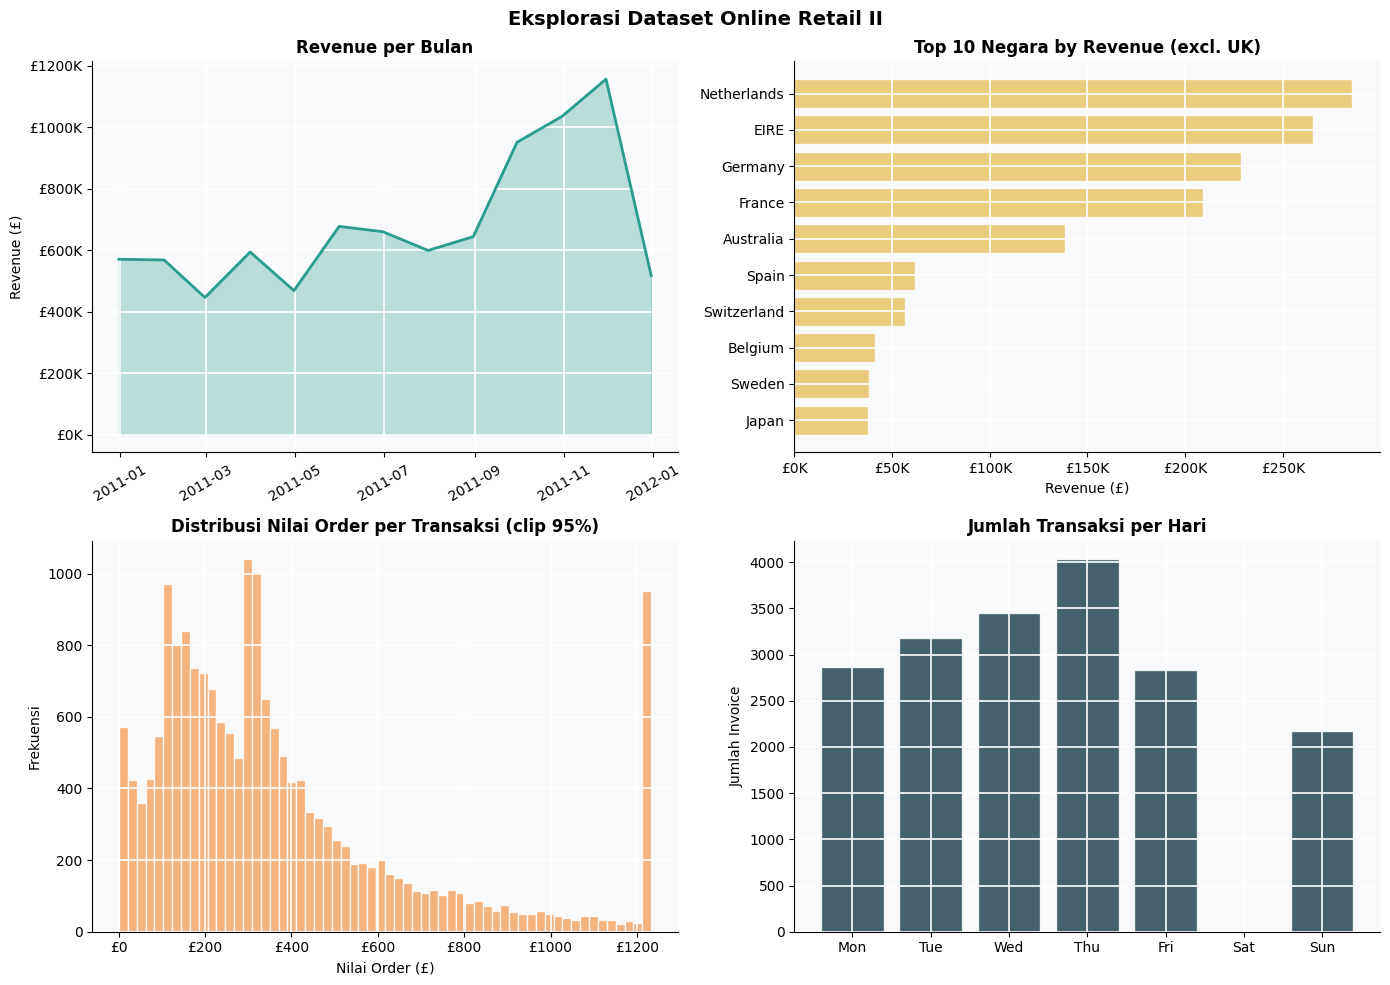

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue per bulan
monthly = df_clean.resample('M', on='InvoiceDate')['TotalPrice'].sum()
axes[0,0].fill_between(monthly.index, monthly.values, alpha=0.3, color=C2)
axes[0,0].plot(monthly.index, monthly.values, color=C2, linewidth=2)
axes[0,0].set_title('Revenue per Bulan', fontweight='bold')
axes[0,0].set_ylabel('Revenue (£)')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0,0].tick_params(axis='x', rotation=30)

# Top 10 negara by revenue (exclude UK karena dominan)
country_rev = (
    df_clean[df_clean['Country'] != 'United Kingdom']
    .groupby('Country')['TotalPrice'].sum()
    .sort_values(ascending=True).tail(10)
)
axes[0,1].barh(country_rev.index, country_rev.values, color=C3, alpha=0.85, edgecolor='white')
axes[0,1].set_title('Top 10 Negara by Revenue (excl. UK)', fontweight='bold')
axes[0,1].set_xlabel('Revenue (£)')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# Distribusi order value per transaksi
order_val = df_clean.groupby('Invoice')['TotalPrice'].sum()
order_val_clip = order_val.clip(0, order_val.quantile(0.95))
axes[1,0].hist(order_val_clip, bins=60, color=C4, alpha=0.8, edgecolor='white')
axes[1,0].set_title('Distribusi Nilai Order per Transaksi (clip 95%)', fontweight='bold')
axes[1,0].set_xlabel('Nilai Order (£)')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))

# Transaksi per hari dalam seminggu
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
trx_per_day = df_clean.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)
axes[1,1].bar(range(7), trx_per_day.values, color=C1, alpha=0.85, edgecolor='white')
axes[1,1].set_xticks(range(7))
axes[1,1].set_xticklabels([d[:3] for d in day_order])
axes[1,1].set_title('Jumlah Transaksi per Hari', fontweight='bold')
axes[1,1].set_ylabel('Jumlah Invoice')

plt.suptitle('Eksplorasi Dataset Online Retail II', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Hitung RFM Score

> Tanggal referensi = 1 hari setelah transaksi terakhir di dataset (simulasi "hari ini")

In [4]:
# Tanggal referensi
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Tanggal referensi: {reference_date.date()}')

# Hitung RFM per customer
rfm = df_clean.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f'\nJumlah pelanggan unik: {len(rfm):,}')
print('\nStatistik RFM')
display(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Tanggal referensi: 2011-12-10

Jumlah pelanggan unik: 4,338

Statistik RFM


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


---
## Binning RFM ke Skor 1–5

5 Baris Pertama RFM Table


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4


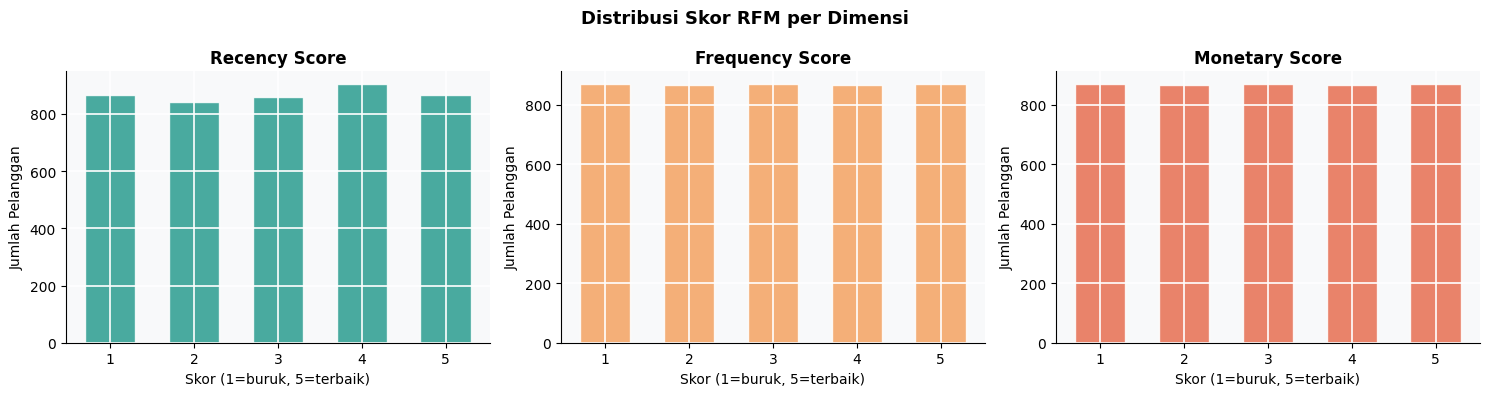

Data RFM disimpan: rfm_table.csv


In [5]:
# Bagi setiap dimensi ke 5 quintile
# Recency: semakin kecil = semakin baik → skor terbalik
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

# Gabungkan jadi RFM Score string dan numerik
rfm['RFM_Score']  = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total']  = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print('5 Baris Pertama RFM Table')
display(rfm.head())

# Distribusi RFM Total Score
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color, label in zip(
    axes,
    ['R_Score', 'F_Score', 'M_Score'],
    [C2, C4, C5],
    ['Recency Score', 'Frequency Score', 'Monetary Score']
):
    counts = rfm[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white', width=0.6)
    ax.set_xlabel('Skor (1=buruk, 5=terbaik)')
    ax.set_ylabel('Jumlah Pelanggan')
    ax.set_title(label, fontweight='bold')
    ax.set_xticks([1,2,3,4,5])

plt.suptitle('Distribusi Skor RFM per Dimensi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_rfm_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan untuk dipakai di notebook berikutnya
rfm.to_csv('rfm_table.csv', index=False)
print('Data RFM disimpan: rfm_table.csv')

---
## Visualisasi Distribusi RFM

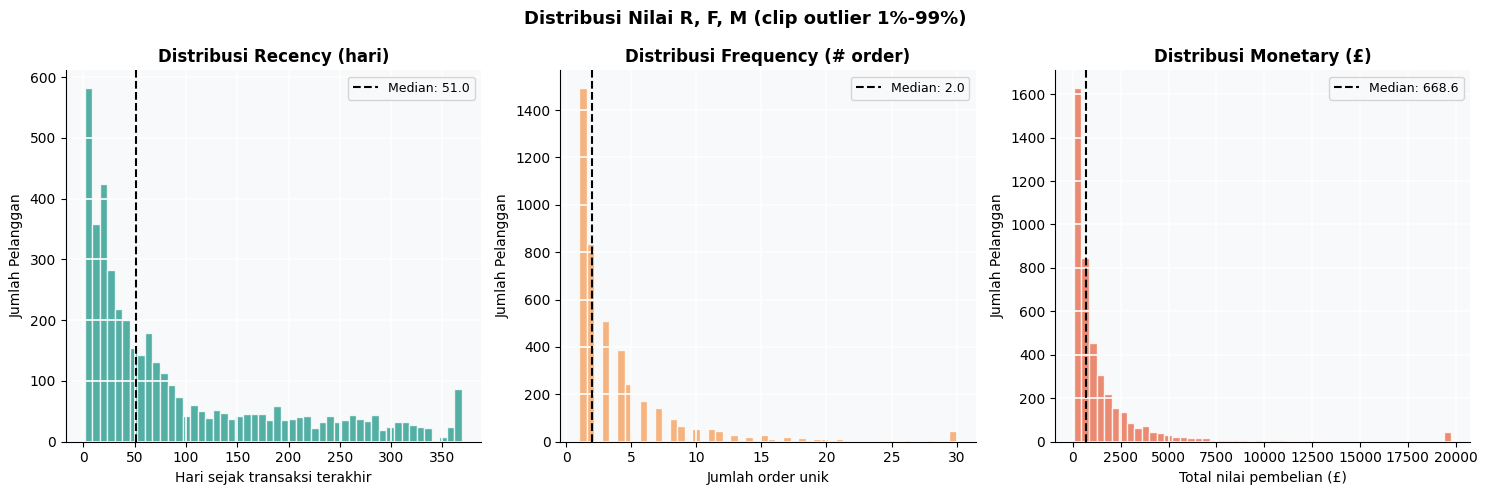

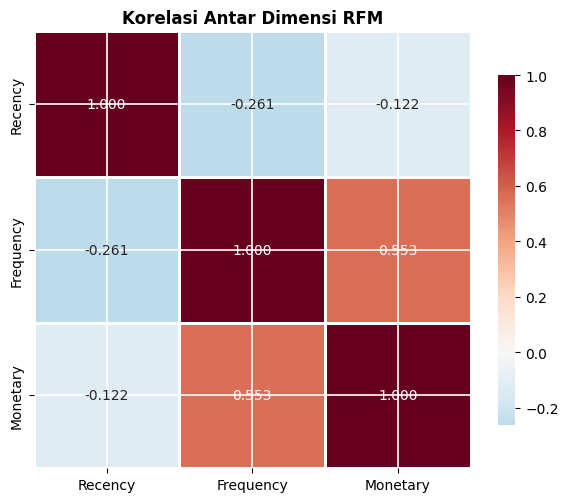

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color, title, xlabel in zip(
    axes,
    ['Recency', 'Frequency', 'Monetary'],
    [C2, C4, C5],
    ['Distribusi Recency (hari)', 'Distribusi Frequency (# order)', 'Distribusi Monetary (£)'],
    ['Hari sejak transaksi terakhir', 'Jumlah order unik', 'Total nilai pembelian (£)']
):
    data = rfm[col].clip(rfm[col].quantile(0.01), rfm[col].quantile(0.99))
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {rfm[col].median():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Jumlah Pelanggan')
    ax.legend(fontsize=9)

plt.suptitle('Distribusi Nilai R, F, M (clip outlier 1%-99%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap korelasi RFM
fig, ax = plt.subplots(figsize=(6, 5))
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=ax, square=True, cbar_kws={'shrink': 0.8},
            linewidths=1, linecolor='white')
ax.set_title('Korelasi Antar Dimensi RFM', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_rfm_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ringkasan RFM

In [7]:
print('   RINGKASAN RFM ANALYSIS')
print(f"""
DATASET
   Pelanggan unik : {len(rfm):,}
   Periode        : {df_clean['InvoiceDate'].min().date()} s/d {df_clean['InvoiceDate'].max().date()}

RECENCY
   Median : {rfm['Recency'].median():.0f} hari
   Min    : {rfm['Recency'].min()} hari (paling aktif)
   Max    : {rfm['Recency'].max()} hari (paling lama tidak beli)

FREQUENCY
   Median : {rfm['Frequency'].median():.0f} order
   Max    : {rfm['Frequency'].max()} order (pelanggan paling loyal)

MONETARY
   Median : £{rfm['Monetary'].median():.2f}
   Total  : £{rfm['Monetary'].sum():,.2f}
   Max    : £{rfm['Monetary'].max():,.2f} (top spender)

NEXT STEP
   → Notebook 2: K-Means Clustering berdasarkan RFM Score
""")

   RINGKASAN RFM ANALYSIS

DATASET
   Pelanggan unik : 4,338
   Periode        : 2010-12-01 s/d 2011-12-09

RECENCY
   Median : 51 hari
   Min    : 1 hari (paling aktif)
   Max    : 374 hari (paling lama tidak beli)

FREQUENCY
   Median : 2 order
   Max    : 209 order (pelanggan paling loyal)

MONETARY
   Median : £668.57
   Total  : £8,887,226.89
   Max    : £280,206.02 (top spender)

NEXT STEP
   → Notebook 2: K-Means Clustering berdasarkan RFM Score

